In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "figure.dpi": 120,
})

In [2]:
# ==========================================================
# VALIDATION DIRECTORY
# ==========================================================

BASE = Path(
    "/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results"
)

# ==========================================================
# FIGURE OUTPUT DIRECTORY
# ==========================================================

FIG_DIR = Path.cwd() / "plots" / "heathcote_validation"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================
# PHYSICAL PARAMETERS
# ==========================================================

# From the validation case
chord = 0.10       # [m]
Uinf = 0.30        # [m/s]

# Prescribed root heaving amplitude
a_root = 0.175 * chord

# Reynolds number
Re = 30000

# ==========================================================
# REDUCED-FREQUENCY SWEEP
# ==========================================================

KG_VALUES = {
    "KG1": 0.3,
    "KG2": 0.8,
    "KG3": 1.3,
    "KG4": 1.8,
}

# Structural cases
STRUCTURES = {
    "inflex": "Inflexible",
    "flex": "Flexible",
    "highflex": "Highly Flexible",
}

print("Base directory:", BASE)
print("Root amplitude:", a_root, "m")

Base directory: /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results
Root amplitude: 0.017499999999999998 m


In [3]:
# ==========================================================
# SWEEP CASE DIRECTORIES
# ==========================================================

SWEEP_CASES = {}

for kg_name, kg_value in KG_VALUES.items():
    for struct_key, struct_label in STRUCTURES.items():

        case_name = f"{kg_name}_{struct_key}"

        SWEEP_CASES[case_name] = {
            "path": BASE / f"results_{case_name}",
            "kg": kg_value,
            "structure": struct_key,
            "label": struct_label,
        }

# ==========================================================
# kG = 1.82 TIP-DISPLACEMENT CASES
# ==========================================================

TIPDISP_KG = 1.82

TIPDISP_CASES = {
    "inflex": BASE / "results_tipdisp_inflex",
    "flex": BASE / "results_tipdisp_flex",
    "highflex": BASE / "results_tipdisp_highflex",
}

# Print sweep cases
for name, info in SWEEP_CASES.items():
    print(
        f"{name:20s} "
        f"kG={info['kg']:.2f}  "
        f"{info['structure']:10s}  "
        f"{info['path']}"
    )

KG1_inflex           kG=0.30  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_inflex
KG1_flex             kG=0.30  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_flex
KG1_highflex         kG=0.30  highflex    /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_highflex
KG2_inflex           kG=0.80  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_inflex
KG2_flex             kG=0.80  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_flex
KG2_highflex         kG=0.80  highflex    /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG2_highflex
KG3_inflex           kG=1.30  inflex      /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG3_inflex
KG3_flex             kG=1.30  flex        /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG3_flex
KG3_highflex         kG=1.30  highflex    /home/dysco/FLOWUnsteady/VarFLEXI-rVPM-F

In [4]:
# ==========================================================
# CHECK DIRECTORY STRUCTURE
# ==========================================================

print("SWEEP CASES")
print("-" * 60)

for name, info in SWEEP_CASES.items():
    path = info["path"]

    status = "FOUND" if path.exists() else "MISSING"

    print(f"{status:8s} : {path.name}")

print("\nTIP-DISPLACEMENT CASES")
print("-" * 60)

for structure, path in TIPDISP_CASES.items():

    status = "FOUND" if path.exists() else "MISSING"

    print(f"{status:8s} : {path.name}")

SWEEP CASES
------------------------------------------------------------
FOUND    : results_KG1_inflex
FOUND    : results_KG1_flex
FOUND    : results_KG1_highflex
FOUND    : results_KG2_inflex
FOUND    : results_KG2_flex
FOUND    : results_KG2_highflex
FOUND    : results_KG3_inflex
FOUND    : results_KG3_flex
FOUND    : results_KG3_highflex
FOUND    : results_KG4_inflex
FOUND    : results_KG4_flex
FOUND    : results_KG4_highflex

TIP-DISPLACEMENT CASES
------------------------------------------------------------
FOUND    : results_tipdisp_inflex
FOUND    : results_tipdisp_flex
FOUND    : results_tipdisp_highflex


In [5]:
# ==========================================================
# FILE DISCOVERY
# ==========================================================

def get_solid_diagnostics_path(case_dir):
    """
    Return:
        case_dir/solid/diagnostics/solid_diagnostics.csv
    """
    path = case_dir / "solid" / "diagnostics" / "solid_diagnostics.csv"

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find solid diagnostics:\n{path}"
        )

    return path


def get_coupling_history_path(case_dir):

    path = case_dir / "coupling" / "coupling_history.csv"

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find coupling history:\n{path}"
        )

    return path


def list_fluid_files(case_dir):

    fluid_dir = case_dir / "fluid"

    if not fluid_dir.exists():
        return []

    return sorted(fluid_dir.iterdir())

In [6]:
# ==========================================================
# INSPECT ONE CASE
# ==========================================================

test_case = SWEEP_CASES["KG1_flex"]["path"]

solid_file = get_solid_diagnostics_path(test_case)

test_df = pd.read_csv(solid_file)

print("File:")
print(solid_file)

print("\nColumns:")
print(test_df.columns.tolist())

print("\nFirst rows:")
display(test_df.head())

File:
/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/results/results_KG1_flex/solid/diagnostics/solid_diagnostics.csv

Columns:
['Step', 'Time', 'Root_Uz', 'Mid_Uz', 'Tip_Uz', 'Root_Vz', 'Mid_Vz', 'Tip_Vz', 'Root_Az', 'Mid_Az', 'Tip_Az', 'ElasticEnergy', 'KineticEnergy', 'DampingEnergy', 'TotalEnergy', 'DeltaE', 'DeltaE_over_E0', 'FluidWork', 'StructuralWork', 'CumFluidWork', 'CumStructuralWork', 'WorkError', 'NewtonIterations', 'NewtonResidual', 'ForceNorm', 'WallTime']

First rows:


,Step,Time,Root_Uz,Mid_Uz,Tip_Uz,Root_Vz,Mid_Vz,Tip_Vz,Root_Az,Mid_Az,...,DeltaE_over_E0,FluidWork,StructuralWork,CumFluidWork,CumStructuralWork,WorkError,NewtonIterations,NewtonResidual,ForceNorm,WallTime
0,1,0.005,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,-1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1,0.000000e+00,0.000000e+00,0.000000
1,2,0.010,9.843349e-09,-2.500062e-10,1.201078e-10,0.000004,-9.917599e-08,4.764606e-08,0.001302,-0.000033,...,478.316956,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2,6.310342e-15,1.967823e-13,1.509340
2,3,0.015,3.936859e-08,7.921205e-10,1.675453e-10,0.000008,5.095763e-07,-2.738404e-08,0.000473,0.000225,...,3354.426460,6.411198e-18,6.412423e-18,6.411198e-18,6.412423e-18,0.000012,2,2.595124e-12,2.068422e-10,1.013022
3,4,0.020,8.856131e-08,1.030236e-08,-4.432731e-09,0.000012,3.280800e-06,-1.799443e-06,0.000956,0.000774,...,9364.815279,1.813973e-16,1.814120e-16,1.878085e-16,1.878244e-16,0.000081,2,1.595519e-11,1.273068e-09,1.447091
4,5,0.025,1.573975e-07,3.665441e-08,-2.629664e-08,0.000016,7.259108e-06,-6.927014e-06,0.000717,0.000810,...,19535.917817,1.476996e-15,1.477043e-15,1.664804e-15,1.664867e-15,0.000032,2,5.158421e-11,4.118511e-09,0.986132


In [7]:
# ==========================================================
# LOAD ROOT AND TIP DISPLACEMENT
# ==========================================================

def load_displacement(case_dir):

    path = get_solid_diagnostics_path(case_dir)

    df = pd.read_csv(path)

    required = [
        "Time",
        "Root_Uz",
        "Tip_Uz",
    ]

    missing = [
        col for col in required
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing columns {missing} in\n{path}\n"
            f"Available columns:\n{df.columns.tolist()}"
        )

    data = pd.DataFrame({
        "time": df["Time"].to_numpy(dtype=float),
        "root_z": df["Root_Uz"].to_numpy(dtype=float),
        "tip_z": df["Tip_Uz"].to_numpy(dtype=float),
    })

    return data

In [8]:
# ==========================================================
# FREQUENCY UTILITIES
# ==========================================================

def kg_to_frequency(kG, Uinf=Uinf, chord=chord):

    f = kG * Uinf / (np.pi * chord)

    return f


def kg_to_period(kG, Uinf=Uinf, chord=chord):

    f = kg_to_frequency(kG, Uinf, chord)

    return 1.0 / f


def kg_to_omega(kG, Uinf=Uinf, chord=chord):

    return 2.0 * np.pi * kg_to_frequency(
        kG,
        Uinf,
        chord
    )


for name, kg in KG_VALUES.items():

    f = kg_to_frequency(kg)
    T = kg_to_period(kg)

    print(
        f"{name}: "
        f"kG={kg:.2f}, "
        f"f={f:.4f} Hz, "
        f"T={T:.4f} s"
    )

KG1: kG=0.30, f=0.2865 Hz, T=3.4907 s
KG2: kG=0.80, f=0.7639 Hz, T=1.3090 s
KG3: kG=1.30, f=1.2414 Hz, T=0.8055 s
KG4: kG=1.80, f=1.7189 Hz, T=0.5818 s


In [9]:
# ==========================================================
# SELECT LAST N COMPLETE CYCLES
# ==========================================================

def select_last_cycles(time, signal, period, n_cycles=5):

    time = np.asarray(time)
    signal = np.asarray(signal)

    t_end = time[-1]

    available_cycles = (t_end - time[0]) / period

    n_use = min(
        n_cycles,
        int(np.floor(available_cycles))
    )

    if n_use < 1:
        raise ValueError(
            "Simulation does not contain one complete cycle."
        )

    t_start = t_end - n_use * period

    mask = time >= t_start

    return time[mask], signal[mask]

In [10]:
# ==========================================================
# HARMONIC FIT
# ==========================================================

def harmonic_fit(time, signal, omega):

    time = np.asarray(time)
    signal = np.asarray(signal)

    X = np.column_stack([
        np.ones_like(time),
        np.sin(omega * time),
        np.cos(omega * time),
    ])

    coeff, *_ = np.linalg.lstsq(
        X,
        signal,
        rcond=None
    )

    mean = coeff[0]
    C = coeff[1]
    D = coeff[2]

    amplitude = np.sqrt(C**2 + D**2)

    # z = A sin(omega*t + phi)
    phase = np.arctan2(D, C)

    fitted = X @ coeff

    return {
        "mean": mean,
        "amplitude": amplitude,
        "phase_rad": phase,
        "phase_deg": np.degrees(phase),
        "fitted": fitted,
    }

In [11]:
# ==========================================================
# EXTRACT VALIDATION METRICS
# ==========================================================

def extract_case_metrics(
    case_dir,
    kG,
    n_cycles=5,
):

    data = load_displacement(case_dir)

    time = data["time"].to_numpy()
    root_z = data["root_z"].to_numpy()
    tip_z = data["tip_z"].to_numpy()

    omega = kg_to_omega(kG)
    period = kg_to_period(kG)

    # Common steady-state window
    t_end = time[-1]

    available_cycles = (
        t_end - time[0]
    ) / period

    n_use = min(
        n_cycles,
        int(np.floor(available_cycles))
    )

    if n_use < 1:
        raise ValueError(
            f"Insufficient simulation duration for {case_dir}"
        )

    t_start = t_end - n_use * period

    mask = time >= t_start

    t_ss = time[mask]
    root_ss = root_z[mask]
    tip_ss = tip_z[mask]

    # Harmonic fits
    root_fit = harmonic_fit(
        t_ss,
        root_ss,
        omega
    )

    tip_fit = harmonic_fit(
        t_ss,
        tip_ss,
        omega
    )

    # Amplitude ratio
    amplitude_ratio = (
        tip_fit["amplitude"]
        /
        root_fit["amplitude"]
    )

    # Phase difference
    phase_diff = (
        tip_fit["phase_deg"]
        -
        root_fit["phase_deg"]
    )

    # Wrap to [-180, 180]
    phase_diff = (
        phase_diff + 180
    ) % 360 - 180

    return {
        "kG": kG,

        "root_amplitude":
            root_fit["amplitude"],

        "tip_amplitude":
            tip_fit["amplitude"],

        "amplitude_ratio":
            amplitude_ratio,

        "root_phase_deg":
            root_fit["phase_deg"],

        "tip_phase_deg":
            tip_fit["phase_deg"],

        "phase_difference_deg":
            phase_diff,

        "n_cycles_used":
            n_use,

        "steady_start_time":
            t_start,

        "steady_end_time":
            t_end,
    }

In [12]:
# ==========================================================
# TEST ONE CASE
# ==========================================================

test_metrics = extract_case_metrics(
    SWEEP_CASES["KG1_flex"]["path"],
    kG=0.3,
    n_cycles=5,
)

test_metrics

{'kG': 0.3,
 'root_amplitude': np.float64(0.012043087041921646),
 'tip_amplitude': np.float64(0.012144008451840356),
 'amplitude_ratio': np.float64(1.0083800282740967),
 'root_phase_deg': np.float64(88.12112540438515),
 'tip_phase_deg': np.float64(88.10964979438326),
 'phase_difference_deg': np.float64(-0.01147561000189512),
 'n_cycles_used': 4,
 'steady_start_time': np.float64(1.0373659840453637),
 'steady_end_time': np.float64(15.0)}

In [13]:
# ==========================================================
# PROCESS FULL kG SWEEP
# ==========================================================

results = []

for case_name, info in SWEEP_CASES.items():

    print(f"Processing {case_name} ...")

    metrics = extract_case_metrics(
        info["path"],
        kG=info["kg"],
        n_cycles=5,
    )

    metrics["case"] = case_name
    metrics["structure"] = info["structure"]
    metrics["structure_label"] = info["label"]

    results.append(metrics)


validation_df = pd.DataFrame(results)

validation_df = validation_df.sort_values(
    ["structure", "kG"]
).reset_index(drop=True)

display(validation_df)

Processing KG1_inflex ...
Processing KG1_flex ...
Processing KG1_highflex ...
Processing KG2_inflex ...
Processing KG2_flex ...
Processing KG2_highflex ...
Processing KG3_inflex ...
Processing KG3_flex ...
Processing KG3_highflex ...
Processing KG4_inflex ...
Processing KG4_flex ...
Processing KG4_highflex ...


,kG,root_amplitude,tip_amplitude,amplitude_ratio,root_phase_deg,tip_phase_deg,phase_difference_deg,n_cycles_used,steady_start_time,steady_end_time,case,structure,structure_label
0,0.3,0.012043,0.012144,1.008380,88.121125,88.109650,-0.011476,4,1.037366,15.0,KG1_flex,flex,Flexible
1,0.8,0.017500,0.018574,1.061394,88.624901,88.728942,0.104041,5,8.455015,15.0,KG2_flex,flex,Flexible
2,1.3,0.017500,0.020537,1.173515,87.765465,87.929525,0.164060,5,10.972317,15.0,KG3_flex,flex,Flexible
3,1.8,0.017500,0.023997,1.371239,86.906028,87.057549,0.151521,5,12.091118,15.0,KG4_flex,flex,Flexible
4,0.3,0.012043,0.012386,1.028464,88.121125,88.078072,-0.043054,4,1.037366,15.0,KG1_highflex,highflex,Highly Flexible
5,0.8,0.017500,0.021476,1.227228,88.624901,88.966827,0.341925,5,8.455015,15.0,KG2_highflex,highflex,Highly Flexible
6,1.3,0.017500,0.031530,1.801731,87.765465,88.349627,0.584163,5,10.972317,15.0,KG3_highflex,highflex,Highly Flexible
7,1.8,0.017500,0.067124,3.835632,86.906028,96.754190,9.848162,5,12.091118,15.0,KG4_highflex,highflex,Highly Flexible
8,0.3,0.012043,0.012060,1.001387,88.121125,88.119280,-0.001845,4,1.037366,15.0,KG1_inflex,inflex,Inflexible
9,0.8,0.017500,0.017673,1.009882,88.624901,88.642459,0.017558,5,8.455015,15.0,KG2_inflex,inflex,Inflexible


In [14]:
# ==========================================================
# SAVE VALIDATION DATA
# ==========================================================

output_csv = (
    FIG_DIR
    / "heathcote_validation_extracted_metrics.csv"
)

validation_df.to_csv(
    output_csv,
    index=False
)

print("Saved:")
print(output_csv)

Saved:
/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/notebooks/plots/heathcote_validation/heathcote_validation_extracted_metrics.csv


In [15]:
# ==========================================================
# AMPLITUDE-RATIO TABLE
# ==========================================================

amplitude_table = validation_df.pivot(
    index="kG",
    columns="structure_label",
    values="amplitude_ratio"
)

display(amplitude_table)

structure_label,Flexible,Highly Flexible,Inflexible
kG,,,
0.3,1.008380,1.028464,1.001387
0.8,1.061394,1.227228,1.009882
1.3,1.173515,1.801731,1.026377
1.8,1.371239,3.835632,1.051385


In [16]:
# ==========================================================
# PHASE-DIFFERENCE TABLE
# ==========================================================

phase_table = validation_df.pivot(
    index="kG",
    columns="structure_label",
    values="phase_difference_deg"
)

display(phase_table)

structure_label,Flexible,Highly Flexible,Inflexible
kG,,,
0.3,-0.011476,-0.043054,-0.001845
0.8,0.104041,0.341925,0.017558
1.3,0.164060,0.584163,0.027406
1.8,0.151521,9.848162,0.035968


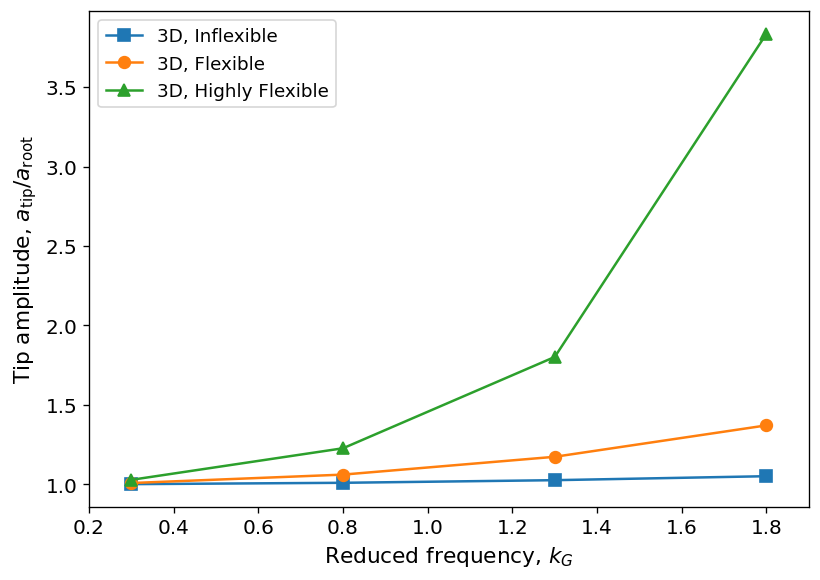

In [17]:
# ==========================================================
# FIGURE: TIP AMPLITUDE / ROOT AMPLITUDE
# ==========================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)

plot_settings = {
    "inflex": {
        "marker": "s",
        "label": "3D, Inflexible",
    },

    "flex": {
        "marker": "o",
        "label": "3D, Flexible",
    },

    "highflex": {
        "marker": "^",
        "label": "3D, Highly Flexible",
    },
}


for structure, settings in plot_settings.items():

    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    ax.plot(
        subset["kG"],
        subset["amplitude_ratio"],
        marker=settings["marker"],
        markersize=7,
        linewidth=1.5,
        label=settings["label"],
    )


ax.set_xlabel(
    r"Reduced frequency, $k_G$"
)

ax.set_ylabel(
    r"Tip amplitude, $a_{\mathrm{tip}}/a_{\mathrm{root}}$"
)

ax.legend()

ax.set_xlim(0.2, 1.9)

ax.grid(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_amplitude_vs_reduced_frequency.pdf",
    bbox_inches="tight"
)

plt.show()

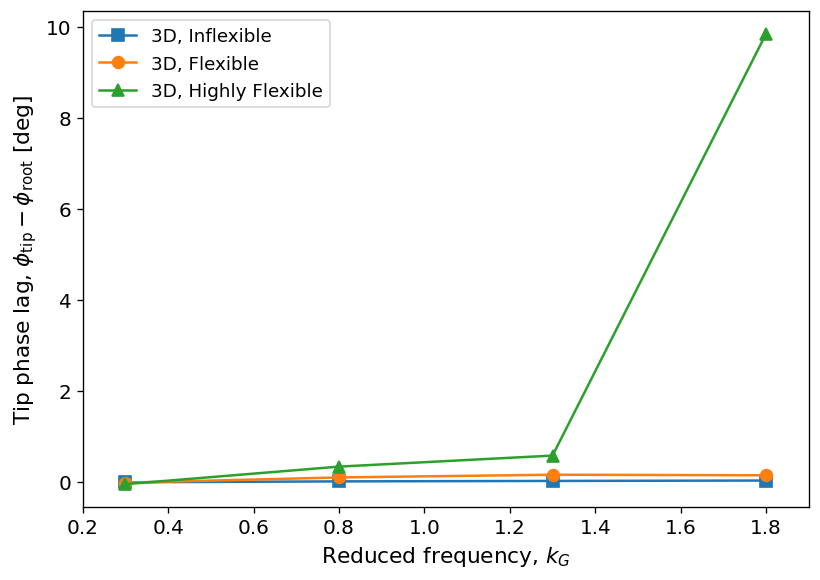

In [18]:
# ==========================================================
# FIGURE: TIP PHASE DIFFERENCE
# ==========================================================

fig, ax = plt.subplots(
    figsize=(7, 5)
)


for structure, settings in plot_settings.items():

    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    ax.plot(
        subset["kG"],
        subset["phase_difference_deg"],
        marker=settings["marker"],
        markersize=7,
        linewidth=1.5,
        label=settings["label"],
    )


ax.set_xlabel(
    r"Reduced frequency, $k_G$"
)

ax.set_ylabel(
    r"Tip phase lag, $\phi_{\mathrm{tip}}-\phi_{\mathrm{root}}$ [deg]"
)

ax.legend()

ax.set_xlim(0.2, 1.9)

ax.grid(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_phase_vs_reduced_frequency.pdf",
    bbox_inches="tight"
)

plt.show()

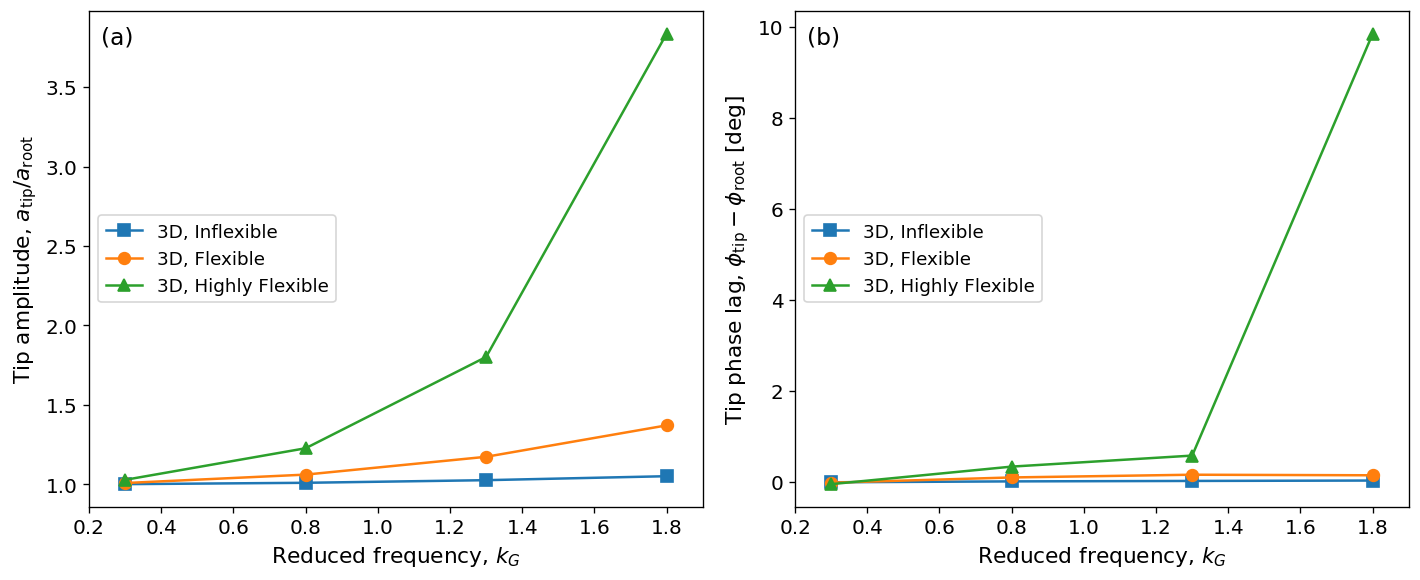

In [19]:
# ==========================================================
# COMBINED VALIDATION FIGURE
# ==========================================================

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)


for structure, settings in plot_settings.items():

    subset = validation_df[
        validation_df["structure"] == structure
    ].sort_values("kG")

    # Amplitude
    ax1.plot(
        subset["kG"],
        subset["amplitude_ratio"],
        marker=settings["marker"],
        markersize=7,
        linewidth=1.5,
        label=settings["label"],
    )

    # Phase
    ax2.plot(
        subset["kG"],
        subset["phase_difference_deg"],
        marker=settings["marker"],
        markersize=7,
        linewidth=1.5,
        label=settings["label"],
    )


# ----------------------------------------------------------
# Panel (a)
# ----------------------------------------------------------

ax1.set_xlabel(
    r"Reduced frequency, $k_G$"
)

ax1.set_ylabel(
    r"Tip amplitude, $a_{\mathrm{tip}}/a_{\mathrm{root}}$"
)

ax1.set_xlim(0.2, 1.9)

ax1.legend()

ax1.text(
    0.02,
    0.97,
    "(a)",
    transform=ax1.transAxes,
    va="top",
    fontsize=14
)


# ----------------------------------------------------------
# Panel (b)
# ----------------------------------------------------------

ax2.set_xlabel(
    r"Reduced frequency, $k_G$"
)

ax2.set_ylabel(
    r"Tip phase lag, $\phi_{\mathrm{tip}}-\phi_{\mathrm{root}}$ [deg]"
)

ax2.set_xlim(0.2, 1.9)

ax2.legend()

ax2.text(
    0.02,
    0.97,
    "(b)",
    transform=ax2.transAxes,
    va="top",
    fontsize=14
)


fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_amplitude_phase_validation.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ==========================================================
# LOAD kG = 1.82 TIP-DISPLACEMENT CASES
# ==========================================================

tipdisp_data = {}

for structure, path in TIPDISP_CASES.items():

    print(
        f"Loading {structure}: "
        f"{path.name}"
    )

    tipdisp_data[structure] = (
        load_displacement(path)
    )

Loading inflex: results_tipdisp_inflex
Loading flex: results_tipdisp_flex
Loading highflex: results_tipdisp_highflex


In [21]:
# ==========================================================
# EXTRACT LAST TWO CYCLES
# ==========================================================

T_tipdisp = kg_to_period(
    TIPDISP_KG
)

tipdisp_steady = {}


for structure, data in tipdisp_data.items():

    time = data["time"].to_numpy()
    root_z = data["root_z"].to_numpy()
    tip_z = data["tip_z"].to_numpy()

    t_end = time[-1]
    t_start = t_end - 2.0 * T_tipdisp

    mask = time >= t_start

    t_selected = time[mask]

    # Reset nondimensional time to 0
    t_nd = (
        t_selected
        -
        t_selected[0]
    ) / T_tipdisp

    tipdisp_steady[structure] = {
        "t_nd": t_nd,
        "root_z": root_z[mask],
        "tip_z": tip_z[mask],
    }

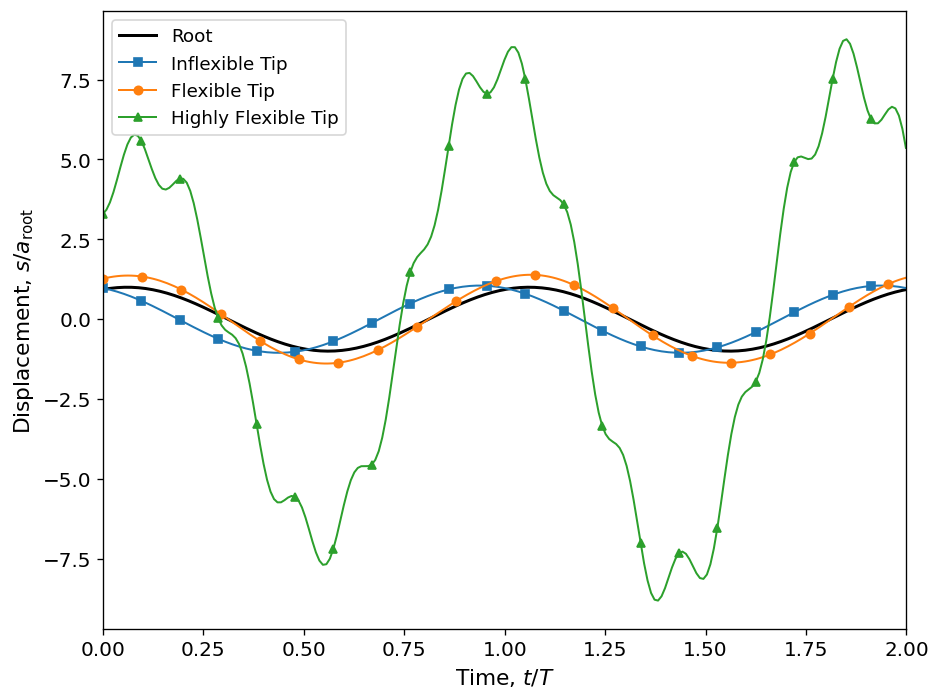

In [22]:
# ==========================================================
# FIGURE: TIP DISPLACEMENT VS TIME AT kG = 1.82
# ==========================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)


# ----------------------------------------------------------
# Root motion
# Use flexible case since root motion should be prescribed
# identically in all cases.
# ----------------------------------------------------------

root_data = tipdisp_steady["flex"]

ax.plot(
    root_data["t_nd"],
    root_data["root_z"] / a_root,
    "k-",
    linewidth=1.8,
    label="Root",
)


# ----------------------------------------------------------
# Inflexible tip
# ----------------------------------------------------------

data = tipdisp_steady["inflex"]

ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    marker="s",
    markevery=max(
        1,
        len(data["t_nd"]) // 20
    ),
    markersize=5,
    linewidth=1.2,
    label="Inflexible Tip",
)


# ----------------------------------------------------------
# Flexible tip
# ----------------------------------------------------------

data = tipdisp_steady["flex"]

ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    marker="o",
    markevery=max(
        1,
        len(data["t_nd"]) // 20
    ),
    markersize=5,
    linewidth=1.2,
    label="Flexible Tip",
)


# ----------------------------------------------------------
# Highly flexible tip
# ----------------------------------------------------------

data = tipdisp_steady["highflex"]

ax.plot(
    data["t_nd"],
    data["tip_z"] / a_root,
    marker="^",
    markevery=max(
        1,
        len(data["t_nd"]) // 20
    ),
    markersize=5,
    linewidth=1.2,
    label="Highly Flexible Tip",
)


ax.set_xlabel(
    r"Time, $t/T$"
)

ax.set_ylabel(
    r"Displacement, $s/a_{\mathrm{root}}$"
)

ax.set_xlim(
    0,
    2
)

ax.legend()

ax.grid(False)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "tip_displacement_kg182_validation.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

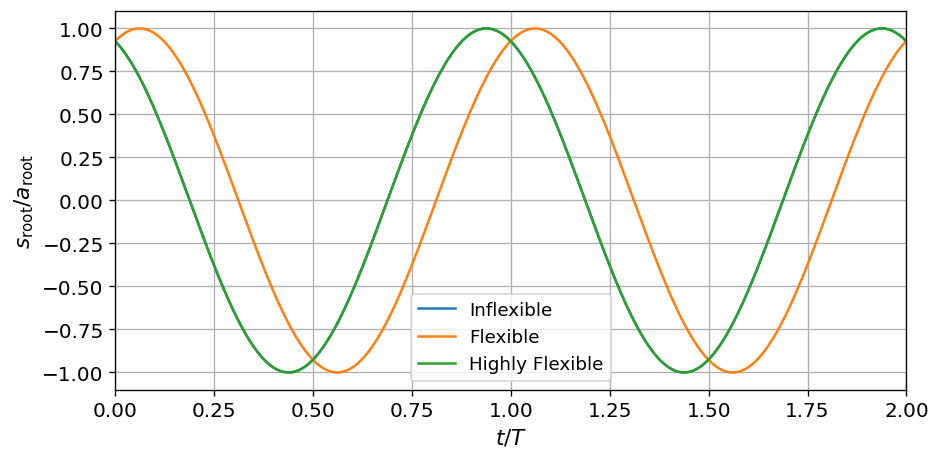

In [23]:
# ==========================================================
# CHECK PRESCRIBED ROOT MOTION
# ==========================================================

fig, ax = plt.subplots(
    figsize=(8, 4)
)

for structure, data in tipdisp_steady.items():

    ax.plot(
        data["t_nd"],
        data["root_z"] / a_root,
        linewidth=1.5,
        label=STRUCTURES[structure],
    )

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    r"$s_{\mathrm{root}}/a_{\mathrm{root}}$"
)

ax.set_xlim(
    0,
    2
)

ax.legend()

ax.grid(True)

fig.tight_layout()

plt.show()

In [24]:
# ==========================================================
# CHECK HARMONIC FIT QUALITY
# ==========================================================

def plot_harmonic_fit(
    case_dir,
    kG,
    n_cycles=5,
):

    data = load_displacement(
        case_dir
    )

    time = data["time"].to_numpy()
    root = data["root_z"].to_numpy()
    tip = data["tip_z"].to_numpy()

    period = kg_to_period(kG)
    omega = kg_to_omega(kG)

    t_end = time[-1]
    t_start = t_end - n_cycles * period

    mask = time >= t_start

    t = time[mask]
    root = root[mask]
    tip = tip[mask]

    root_fit = harmonic_fit(
        t,
        root,
        omega
    )

    tip_fit = harmonic_fit(
        t,
        tip,
        omega
    )

    t_nd = (
        t - t[0]
    ) / period

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.plot(
        t_nd,
        root,
        label="Root data",
        linewidth=1.5
    )

    ax.plot(
        t_nd,
        root_fit["fitted"],
        "--",
        label="Root harmonic fit",
        linewidth=2
    )

    ax.plot(
        t_nd,
        tip,
        label="Tip data",
        linewidth=1.5
    )

    ax.plot(
        t_nd,
        tip_fit["fitted"],
        "--",
        label="Tip harmonic fit",
        linewidth=2
    )

    ax.set_xlabel(
        r"$t/T$"
    )

    ax.set_ylabel(
        "Displacement [m]"
    )

    ax.legend()

    ax.grid(True)

    fig.tight_layout()

    plt.show()

In [25]:
# ==========================================================
# PAPER-READY VALIDATION SUMMARY
# ==========================================================

summary = validation_df[
    [
        "kG",
        "structure_label",
        "root_amplitude",
        "tip_amplitude",
        "amplitude_ratio",
        "phase_difference_deg",
        "n_cycles_used",
    ]
].copy()

summary.columns = [
    "k_G",
    "Configuration",
    "a_root [m]",
    "a_tip [m]",
    "a_tip/a_root",
    "Phase difference [deg]",
    "Cycles used",
]

display(
    summary.sort_values(
        ["k_G", "Configuration"]
    )
)

,k_G,Configuration,a_root [m],a_tip [m],a_tip/a_root,Phase difference [deg],Cycles used
0,0.3,Flexible,0.012043,0.012144,1.008380,-0.011476,4
4,0.3,Highly Flexible,0.012043,0.012386,1.028464,-0.043054,4
8,0.3,Inflexible,0.012043,0.012060,1.001387,-0.001845,4
1,0.8,Flexible,0.017500,0.018574,1.061394,0.104041,5
5,0.8,Highly Flexible,0.017500,0.021476,1.227228,0.341925,5
9,0.8,Inflexible,0.017500,0.017673,1.009882,0.017558,5
2,1.3,Flexible,0.017500,0.020537,1.173515,0.164060,5
6,1.3,Highly Flexible,0.017500,0.031530,1.801731,0.584163,5
10,1.3,Inflexible,0.017500,0.017962,1.026377,0.027406,5
3,1.8,Flexible,0.017500,0.023997,1.371239,0.151521,5


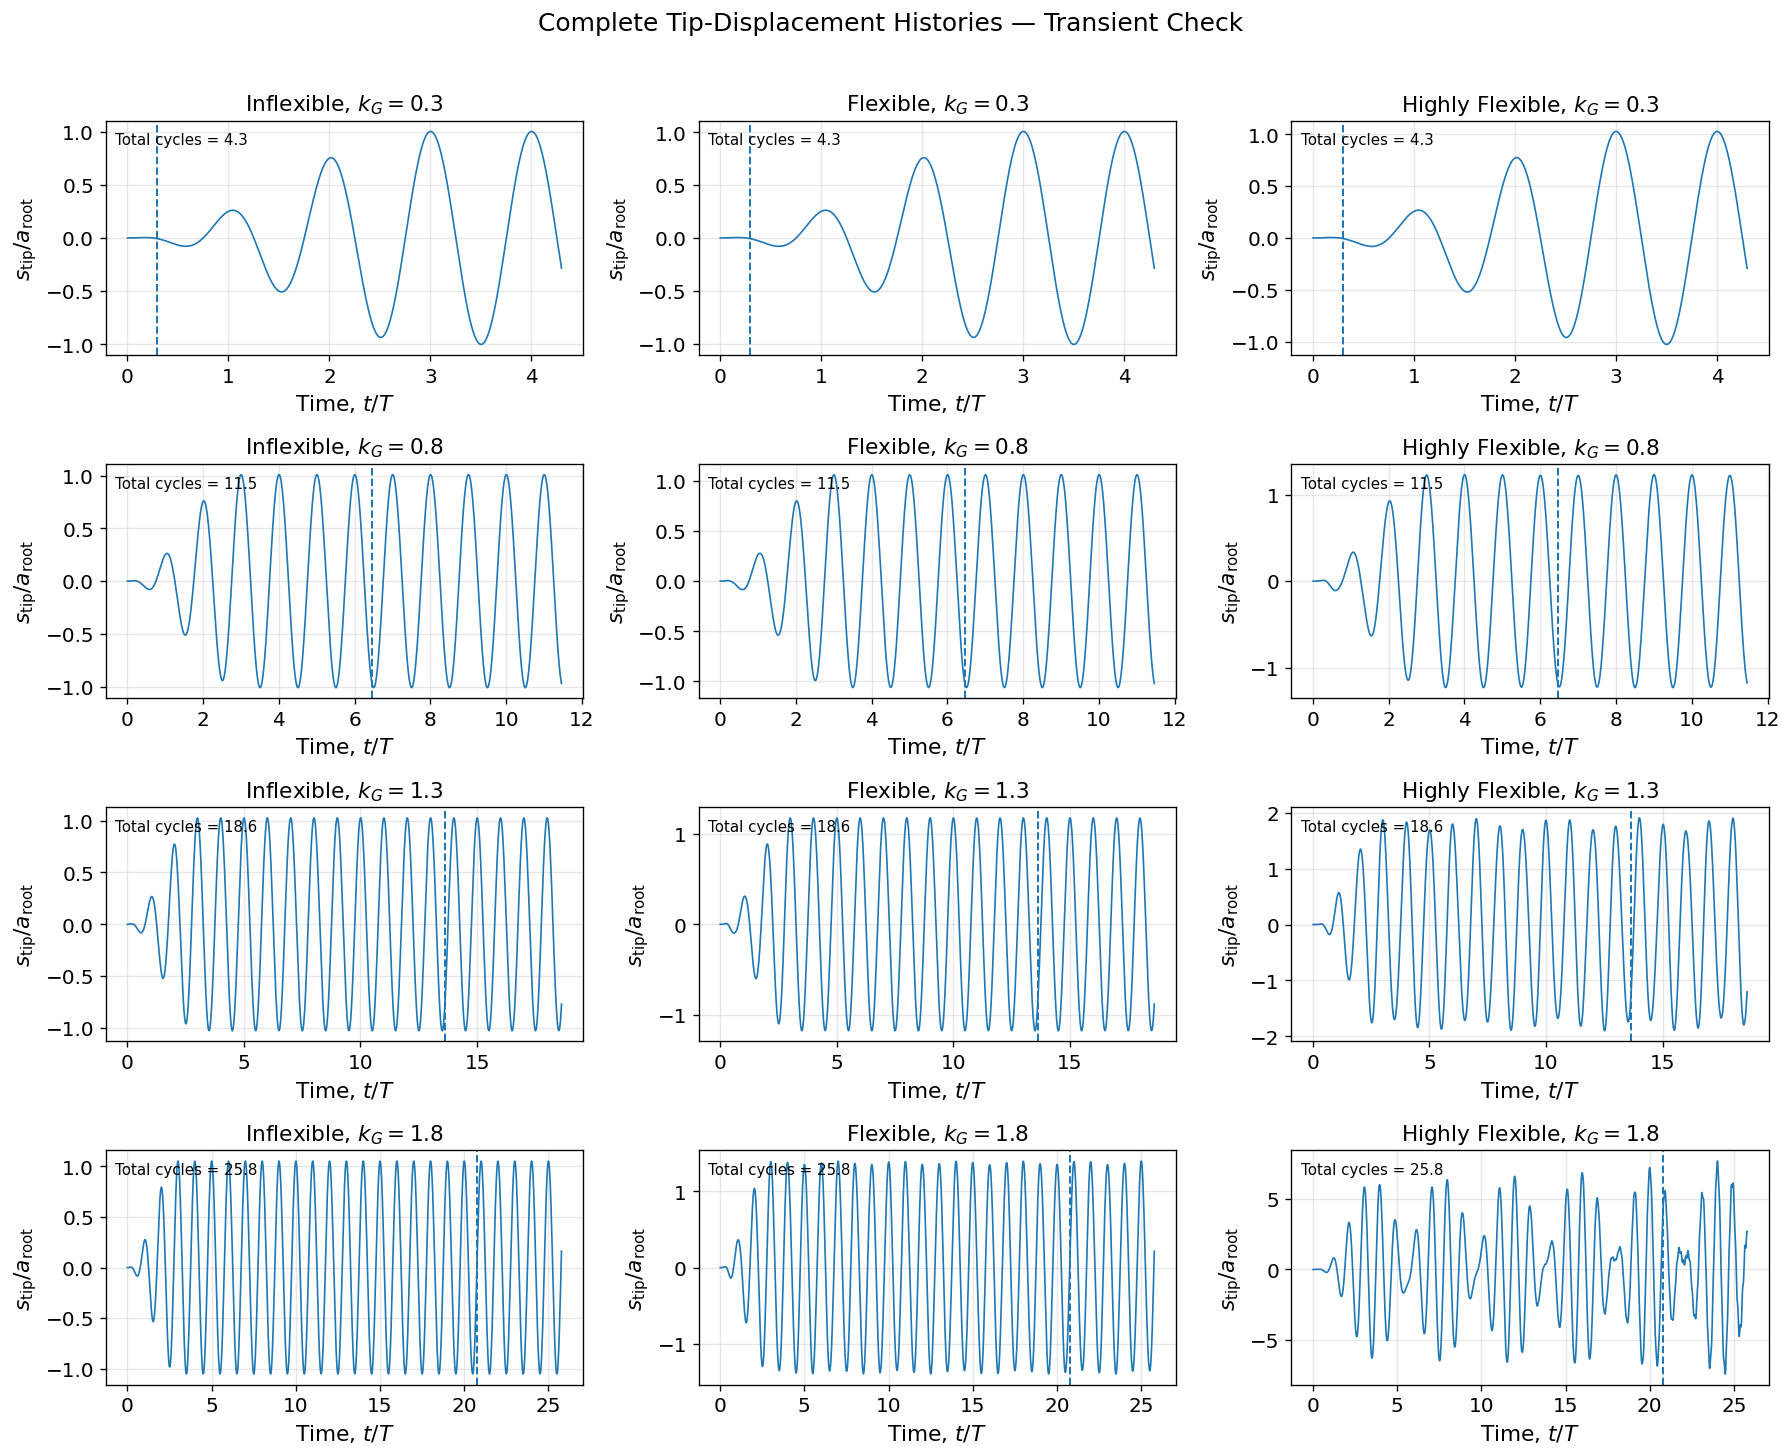

In [26]:
# ==========================================================
# TRANSIENT CHECK:
# COMPLETE TIP-DISPLACEMENT TIME HISTORIES FOR ALL SWEEP CASES
# ==========================================================

fig, axes = plt.subplots(
    4,
    3,
    figsize=(15, 12),
    sharex=False,
    sharey=False,
)

kg_order = [
    ("KG1", 0.3),
    ("KG2", 0.8),
    ("KG3", 1.3),
    ("KG4", 1.8),
]

structure_order = [
    ("inflex", "Inflexible"),
    ("flex", "Flexible"),
    ("highflex", "Highly Flexible"),
]


for i, (kg_name, kg_value) in enumerate(kg_order):

    T = kg_to_period(kg_value)

    for j, (structure, structure_label) in enumerate(structure_order):

        ax = axes[i, j]

        case_name = f"{kg_name}_{structure}"
        case_dir = SWEEP_CASES[case_name]["path"]

        # Load complete simulation
        data = load_displacement(case_dir)

        time = data["time"].to_numpy()
        tip_z = data["tip_z"].to_numpy()

        # Nondimensional time
        t_nd = time / T

        # Nondimensional displacement
        tip_nd = tip_z / a_root

        ax.plot(
            t_nd,
            tip_nd,
            linewidth=1.0,
        )

        # --------------------------------------------------
        # Show where the final 5-cycle fitting window starts
        # --------------------------------------------------

        n_fit_cycles = 5

        total_cycles = (
            time[-1] - time[0]
        ) / T

        n_use = min(
            n_fit_cycles,
            int(np.floor(total_cycles))
        )

        if n_use >= 1:

            t_fit_start = (
                time[-1]
                -
                n_use * T
            )

            t_fit_start_nd = (
                t_fit_start / T
            )

            ax.axvline(
                t_fit_start_nd,
                linestyle="--",
                linewidth=1.2,
                label="Fit window start"
                if (i == 0 and j == 0)
                else None,
            )

        # --------------------------------------------------
        # Labels
        # --------------------------------------------------

        ax.set_title(
            f"{structure_label}, "
            rf"$k_G={kg_value}$"
        )

        ax.set_xlabel(
            r"Time, $t/T$"
        )

        ax.set_ylabel(
            r"$s_{\mathrm{tip}}/a_{\mathrm{root}}$"
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        # Number of simulated cycles
        ax.text(
            0.02,
            0.95,
            f"Total cycles = {total_cycles:.1f}",
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=9,
        )


fig.suptitle(
    "Complete Tip-Displacement Histories — Transient Check",
    fontsize=15,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    FIG_DIR
    / "all_cases_tip_displacement_transient_check.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()